# Task 1
## EDA on Retail Sales Data

### Import Libraries

In [1]:
#importing required libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#### Observations : 
I have imported all the necessary libraries such as numpy to handle numerical values, pandas for data, matplotlib for plotting graphs, seaborn for better vizualization.

### Dataset loading

In [2]:
#loading dataset
df=pd.read_csv("retail_sales_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


#### Observation :
I have loaded the dataset Successfully using pandas. Using df.info() I have checked all the information about the data inside the dataset and Using df.head() I saw the first five lines of data of the dataset

### Inspection (Shape, dtype, isnull)

In [4]:
#for inspection (shape, dtype, isnull)
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(1000, 9)
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [5]:
#changed datatype of date from object to datetime
df['Date']=pd.to_datetime(df['Date'])

In [6]:
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [7]:
df['Date']

0     2023-11-24
1     2023-02-27
2     2023-01-13
3     2023-05-21
4     2023-05-06
         ...    
995   2023-05-16
996   2023-11-17
997   2023-10-29
998   2023-12-05
999   2023-04-12
Name: Date, Length: 1000, dtype: datetime64[ns]

#### Observation :
I have verified the shape that matches the expected rows/columns, data types are correct (convert Date using pd.to_datetime), and null counts are minimal and handled. 

### Descriptive Statistics

In [8]:
#Descriptive Statistics
df.describe(include=[np.number])

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
#mode
df.mode().iloc[0]

Transaction ID                        1
Date                2023-05-16 00:00:00
Customer ID                     CUST001
Gender                           Female
Age                                43.0
Product Category               Clothing
Quantity                            4.0
Price per Unit                     50.0
Total Amount                       50.0
Name: 0, dtype: object

#### Observation :
I have reviewed the mean, median, mode and standard deviation for numerical fields like Age, Quantity, Price per Unit, and Total Amount to spot potential skewness or extreme pricing outliers. 

### Time Series Analysis

In [10]:
#Creating Month column
df["Month"]=df["Date"].dt.to_period("M")

In [11]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05


In [12]:
#Calculating Monthly sales 
Monthly_sales=df.groupby("Month")["Total Amount"].sum()

In [14]:
Monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

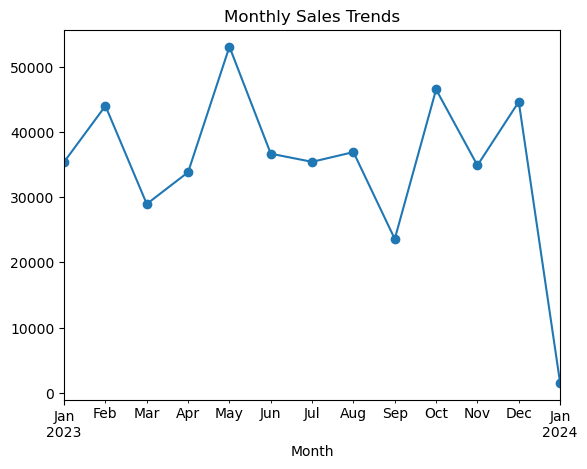

In [52]:
#Plotting Monthly sales trends using line chart 
Monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trends")
plt.show()

#### Observation :
Sales fluctuate seasonally, with sharp peaks indicating high-demand shopping months or holiday surges.

In [16]:
#Creating Quarter Column
df["Quarter"]=df["Date"].dt.to_period("Q")

In [17]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2


In [55]:
#Calculating Quarterly sales trends using line chart
Quarterly_sales=df.groupby("Quarter")["Total Amount"].sum()

In [19]:
Quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

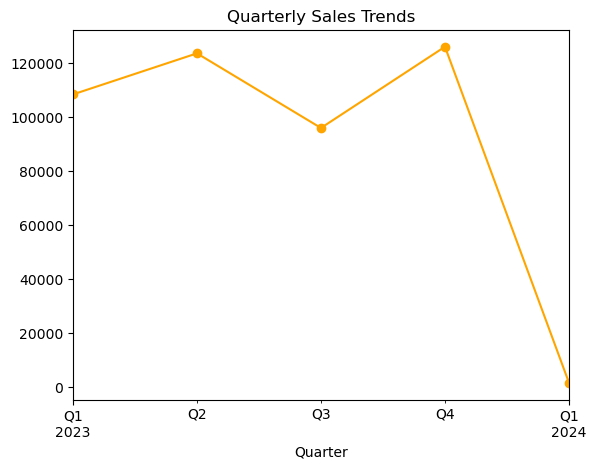

In [57]:
#plotting Quarterly sales 
Quarterly_sales.plot(kind="line",marker="o", color="orange")
plt.title("Quarterly Sales Trends")
plt.show()

#### Observation :
Quarterly sales trends plotted by calculating quarter sales by total amount

### Customer Demographics Analysis

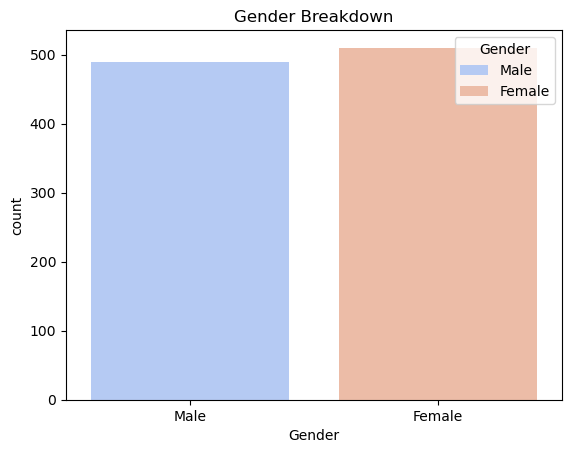

In [40]:
#Customer demographics analysis for Gender Breakdown
sns.countplot(data=df, x="Gender", hue="Gender",palette="coolwarm",legend=True)
plt.title("Gender Breakdown")
plt.show()

#### Observation :
The customer base is nearly balanced by gender, with a slightly higher number of female customers.

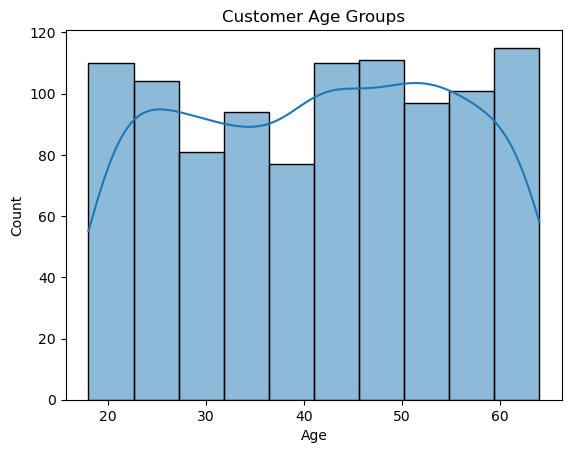

In [44]:
#Customer demographics analysis for Customer Age groups
sns.histplot(data=df, x="Age", bins=10, kde=True)
plt.title("Customer Age Groups")
plt.show()

#### Observation :
Customers are fairly evenly distributed across all age groups with no dominant age segment.

### Product Analysis

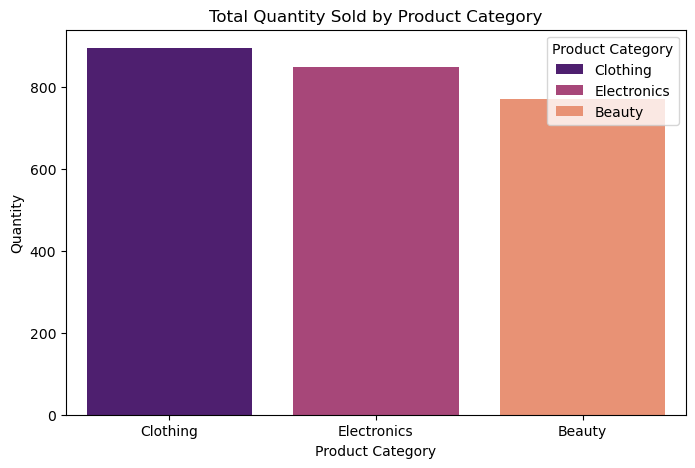

In [41]:
#Product Analysis for Top 10 Product Categories by Quantity
top_products = df.groupby("Product Category")["Quantity"].sum().nlargest(10).reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=top_products, x="Product Category", y="Quantity",hue="Product Category", palette="magma", legend=True)
plt.title("Total Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.show()

#### Observation :
Clothing records the highest quantity sold, indicating the greatest customer demand.

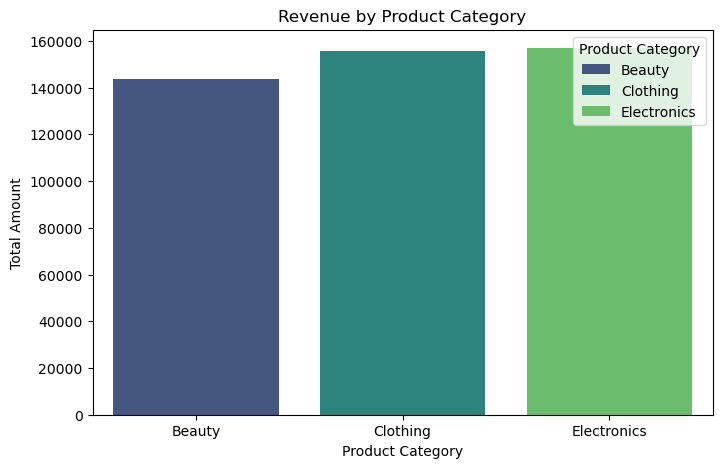

In [46]:
#Revenue by Product Category
Sales_Revenue = df.groupby("Product Category")["Total Amount"].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=Sales_Revenue, x="Product Category", y="Total Amount",hue="Product Category", palette="viridis", legend=True)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

#### Observation :
Electronics generates the highest revenue, followed by Clothing, while Beauty contributes the least.

### Correlation Heatmap

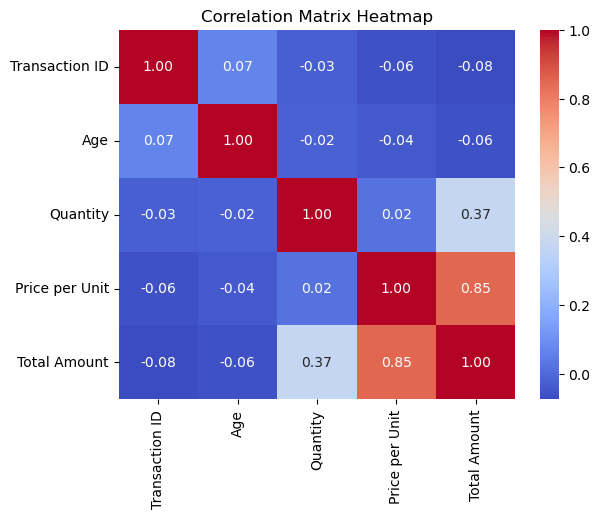

In [49]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

#### Observation :
Price per Unit has the strongest positive correlation with Total Amount, while Age has minimal influence on purchasing behavior.

### Additional Insights

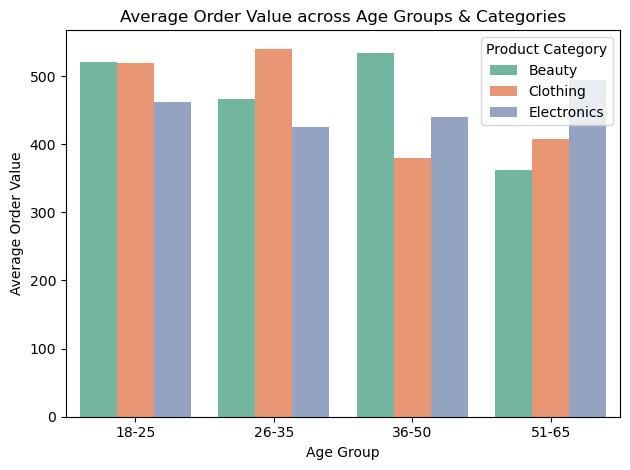

In [74]:
#Additional Insights
age_bins = [17, 25, 35, 50, 65]
age_labels = ['18-25', '26-35', '36-50', '51-65']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
ax = sns.barplot(
    data=df,
    x='Age Group',
    y='Total Amount',
    hue='Product Category',
    estimator='mean',       # Calculates Average Order Value
    errorbar=None,          # Removes confidence interval lines
    palette='Set2'          
)
plt.title('Average Order Value across Age Groups & Categories')
plt.xlabel('Age Group')
plt.ylabel('Average Order Value')
plt.legend(title="Product Category")
plt.tight_layout()
plt.show()

#### Observation :
Average order value varies across age groups, with different product categories being preferred by different age segments.

## Conclusion:
### Business Recommendations based on findings:
#### 1. Shift Marketing Focus to Young Adults (18-25) for High-Value Sales:
&emsp;The Average Order Value chart reveals that the youngest group (18-25) spends the most money per transaction on both Beauty and Clothing, rivaling or beating older age &emsp;groups.
##### &emsp;The Plan: 
&emsp;Focus your social media advertising on this 18-25 age bracket. Promote your premium clothing items and high-end beauty bundles directly to them, as they are proven to &emsp;spend more per order.
#### 2. Lower the Price or Bundle Electronics to Drive Volume
&emsp;The Revenue chart shows Electronics brings in the most total money and the Total Quantity Sold chart reveals it actually sells fewer individual physical items than Clothing.
##### &emsp;The Plan: 
&emsp;Create small, lower-priced electronic accessories or offer on secondary electronics. This will help clear out warehouse stock and increase the total number of items moving &emsp;out the door.
#### 3. Launch an End of Spring Sale
&emsp;The Monthly Sales Trends chart shows a massive revenue peak in May, followed by a sharp drop into June and July.
##### &emsp;The Plan: 
&emsp;Capitalize on this natural shopping surge by hosting a major promotional event in mid to late May. Use this high traffic period to clear out older inventory before the slow &emsp;summer months hit.